In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
test=cv2.imread("../assets/histogram.jpg",0)

In [3]:
def calc_hist(image):
    hist=cv2.calcHist([image],[0],None,[256],[0,256])
    hist=hist.flatten()
    return hist

In [4]:
def calc_pdf(image):
    L=256
    M,N=image.shape
    total_pixels=M*N
    prob=np.zeros(L,dtype=np.float32)
    hist=calc_hist(image)
    for i in range(L):
        prob[i]=hist[i]/total_pixels
    return prob

In [5]:
def calc_cdf(prob):
    L=256
    cdf=np.zeros(L,dtype=np.float32)
    for i in range(L):
        cum_sum=0.0
        for j in range(i+1):
            cum_sum+=prob[j]
        cdf[i]=cum_sum
    return cdf

In [6]:
def erlang_pdf(x,k,lam):
    if k<=0 or lam<=0:
        return 0
    if x<=0:
        return 0
    try:
        nu=(lam**k)*(x**(k-1))*np.exp(-lam*x)
        de=math.factorial(k-1)
        result=nu/de
        if np.isnan(result) or np.isinf(result):
            return 0
        return result
    except:
        return 0

In [7]:
def target_hist(k,lam):
    L=256
    hist=np.zeros(L,dtype=np.float32)
    
    max_x=max(20,k/lam*2)
    
    for i in range(L):
        x=max(0.01,i*max_x/255.0)
        hist[i]=erlang_pdf(x,k,lam)
    
    hist_sum=hist.sum()
    if hist_sum>0:
        hist=hist/hist_sum
        hist=hist*test.size
    else:
        hist=np.ones(L,dtype=np.float32)*test.size/L
    
    return hist

In [8]:
def hist_matching(image, k, lam):

    src_hist=calc_hist(image)
    src_pdf=calc_pdf(image)
    src_cdf=calc_cdf(src_pdf)
    
    tgt_hist=target_hist(k,lam)
    
    tgt_sum=tgt_hist.sum()
    if tgt_sum>0:
        tgt_pdf=tgt_hist/tgt_sum
    else:
        tgt_pdf= np.ones(256, dtype=np.float32)/256
    
    tgt_cdf=calc_cdf(tgt_pdf)
    
    mapping=np.zeros(256,dtype=np.uint8)
    
    for i in range(256):
        diff = np.abs(tgt_cdf-src_cdf[i])
        mapping[i] = np.argmin(diff)
    
    transformed_image=cv2.LUT(image, mapping)
    
    return (transformed_image,src_hist, src_pdf,src_cdf,tgt_hist,tgt_pdf, tgt_cdf,mapping)

In [9]:
def show_results(image,transformed_image,src_hist,src_pdf,src_cdf,tgt_hist,tgt_pdf,tgt_cdf,k,lam):

    trans_hist=calc_hist(transformed_image)
    trans_pdf=calc_pdf(transformed_image)
    trans_cdf=calc_cdf(trans_pdf)
    
    plt.figure(figsize=(20,15))
    
    plt.subplot(3, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(3, 4, 2)
    plt.bar(range(256), src_hist, width=1.0, color='blue', alpha=0.7)
    plt.title('Original Histogram')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    

    plt.subplot(3, 4, 3)
    plt.plot(range(256), src_pdf, color='blue', linewidth=2)
    plt.title('Original PDF')
    plt.xlabel('Pixel Value')
    plt.ylabel('Probability')
    

    plt.subplot(3, 4, 4)
    plt.plot(range(256), src_cdf, color='blue', linewidth=2)
    plt.title('Original CDF')
    plt.xlabel('Pixel Value')
    plt.ylabel('Cumulative Probability')
    

    plt.subplot(3, 4, 5)
    x_range=np.linspace(0.1,8,200)
    erlang_values=[]
    for x in x_range:
        erlang_values.append(erlang_pdf(x,k,lam))
    plt.plot(x_range,erlang_values,'r-',linewidth=2)
    plt.title(f'Erlang Distribution\nk={k}, λ={lam}')
    plt.xlabel('x')
    plt.ylabel('PDF')
    plt.grid(True,alpha=0.3)
    

    plt.subplot(3, 4, 6)
    plt.bar(range(256), tgt_hist, width=1.0, color='red', alpha=0.7)
    plt.title('Target Histogram')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    
    plt.subplot(3, 4, 7)
    plt.plot(range(256), tgt_pdf, color='red', linewidth=2)
    plt.title('Target Erlang PDF')
    plt.xlabel('Pixel Value')
    plt.ylabel('Probability')
    
    plt.subplot(3, 4, 8)
    plt.plot(range(256), tgt_cdf, color='red', linewidth=2)
    plt.title('Target Erlang CDF')
    plt.xlabel('Pixel Value')
    plt.ylabel('Cumulative Probability')

    plt.subplot(3, 4, 9)
    plt.imshow(transformed_image, cmap='gray')
    plt.title('Transformed Image')
    plt.axis('off')
    
    plt.subplot(3, 4, 10)
    plt.bar(range(256), trans_hist, width=1.0, color='green', alpha=0.7)
    plt.title('Transformed Histogram')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    
    plt.subplot(3, 4, 11)
    plt.plot(range(256), trans_pdf, color='green', linewidth=2)
    plt.title('Transformed PDF')
    plt.xlabel('Pixel Value')
    plt.ylabel('Probability')
    
    plt.subplot(3, 4, 12)
    plt.plot(range(256), trans_cdf, color='green', linewidth=2)
    plt.title('Transformed CDF')
    plt.xlabel('Pixel Value')
    plt.ylabel('Cumulative Probability')
    
    plt.tight_layout()
    plt.show()

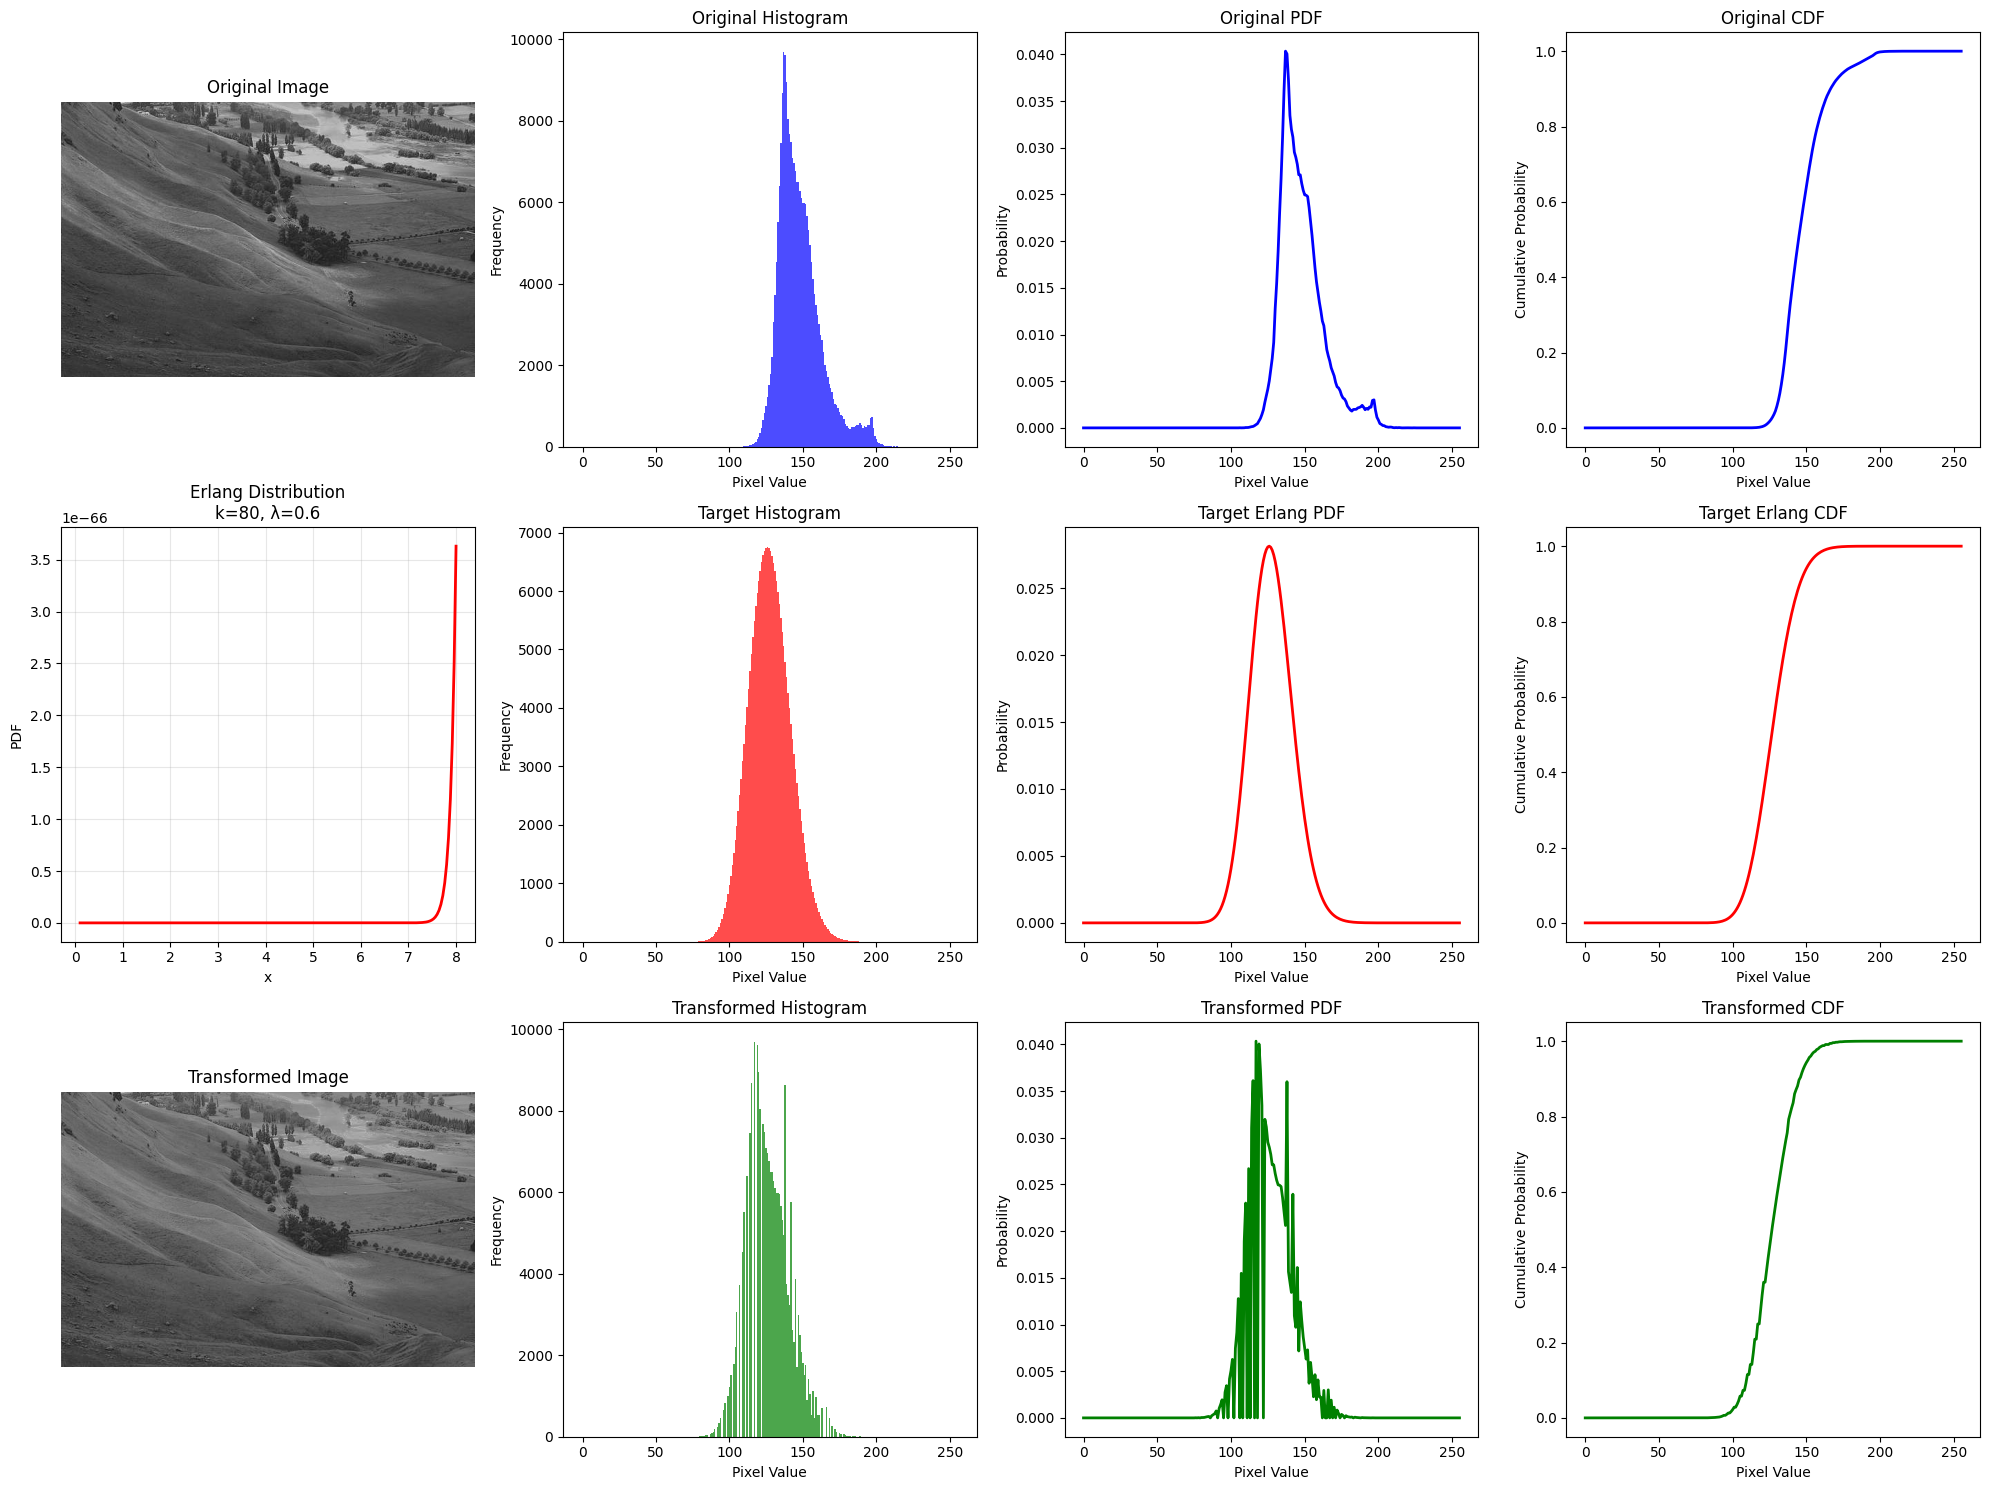

In [10]:
k,lam=80,0.6
result=hist_matching(test,k,lam)


transformed_image,src_hist,src_pdf,src_cdf,tgt_hist,tgt_pdf,tgt_cdf,mapping=result

show_results(test,transformed_image,src_hist,src_pdf,src_cdf,tgt_hist,tgt_pdf,tgt_cdf,k,lam)

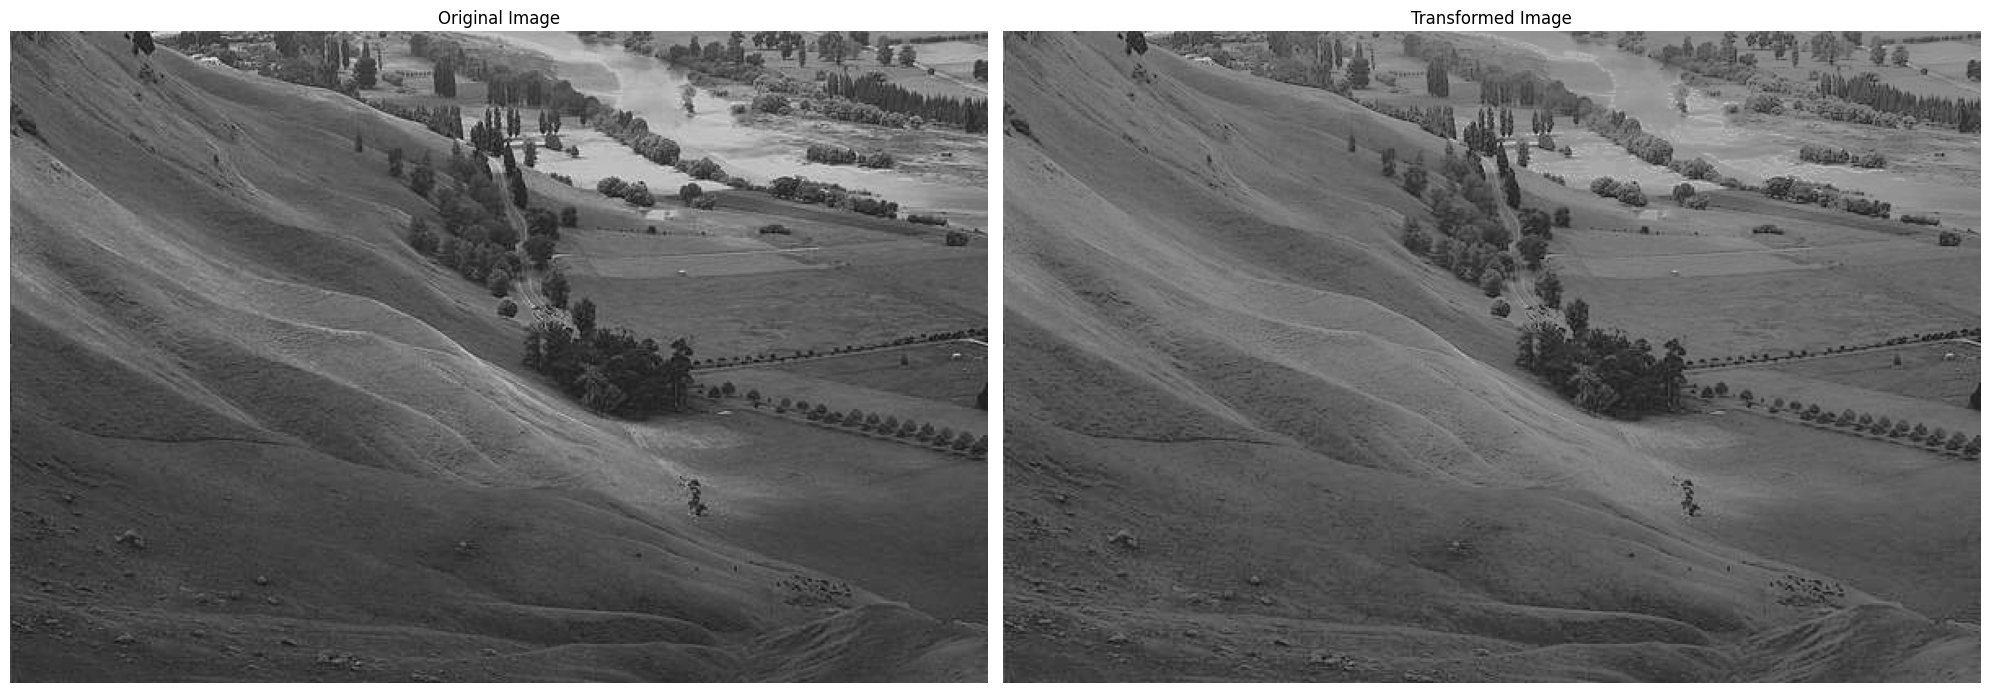

In [11]:
plt.figure(figsize=(20, 15))

plt.subplot(1,2,1)

plt.imshow(test, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(transformed_image, cmap='gray')
plt.title('Transformed Image')
plt.axis('off')

plt.tight_layout()
plt.show()
